In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [134]:
ls


sample_submission.csv  test.csv  train.csv  Untitled.ipynb


# EDA #

In [135]:
ndf=pd.read_csv('train.csv')

In [136]:
ndf['HomePlanet'].unique()

array(['Europa', 'Earth', 'Mars', nan], dtype=object)

In [137]:
df= pd.read_csv('train.csv')

<Axes: >

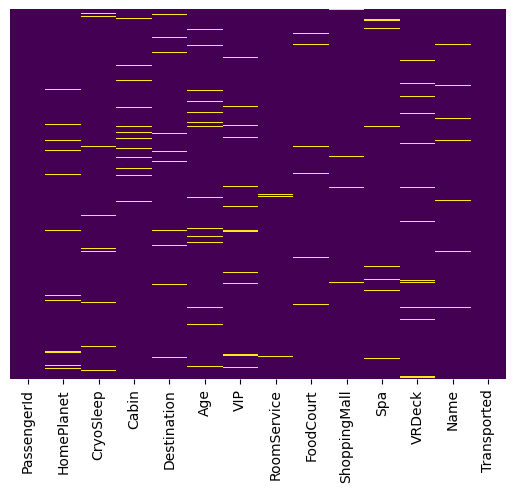

In [138]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [139]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [140]:
df.tail()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False
8692,9280_02,Europa,False,E/608/S,TRAPPIST-1e,44.0,False,126.0,4688.0,0.0,0.0,12.0,Propsh Hontichre,True


In [141]:
df.drop('PassengerId',axis=1, inplace=True)
df.drop('Cabin',axis=1,inplace=True)
df.drop('Name',axis=1,inplace=True)

In [143]:
df['HomePlanet'].unique()

array(['Europa', 'Earth', 'Mars', nan], dtype=object)

In [144]:
df.dropna(axis=0,inplace=True)

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6764 entries, 0 to 8692
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    6764 non-null   object 
 1   CryoSleep     6764 non-null   object 
 2   Cabin         6764 non-null   object 
 3   Destination   6764 non-null   object 
 4   Age           6764 non-null   float64
 5   VIP           6764 non-null   object 
 6   RoomService   6764 non-null   float64
 7   FoodCourt     6764 non-null   float64
 8   ShoppingMall  6764 non-null   float64
 9   Spa           6764 non-null   float64
 10  VRDeck        6764 non-null   float64
 11  Transported   6764 non-null   bool   
dtypes: bool(1), float64(6), object(5)
memory usage: 640.7+ KB


<Axes: >

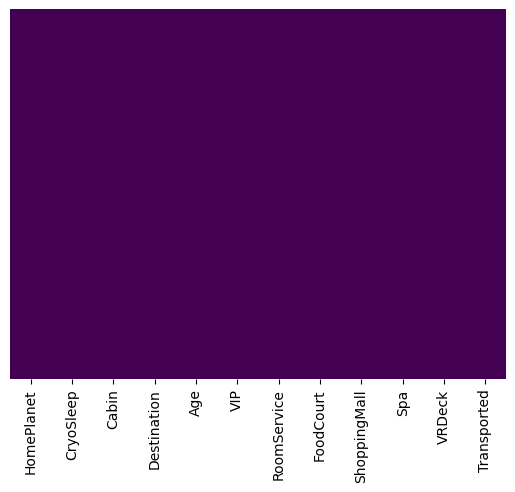

In [146]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [147]:
df['HomePlanet'].unique()

array(['Europa', 'Earth', 'Mars'], dtype=object)

In [148]:
df['CryoSleep'].unique() #binarizar

array([False, True], dtype=object)

In [149]:
df['CryoSleep']=df['CryoSleep'].astype(int)
df['VIP']=df['VIP'].astype(int)
df['Target']=df['Transported'].astype(int)

In [150]:
df.drop('Transported',axis=1,inplace=True)

In [151]:
df

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Target
0,Europa,0,B/0/P,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.0,0
1,Earth,0,F/0/S,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.0,1
2,Europa,0,A/0/S,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0
3,Europa,0,A/0/S,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0
4,Earth,0,F/1/S,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
8688,Europa,0,A/98/P,55 Cancri e,41.0,1,0.0,6819.0,0.0,1643.0,74.0,0
8689,Earth,1,G/1499/S,PSO J318.5-22,18.0,0,0.0,0.0,0.0,0.0,0.0,0
8690,Earth,0,G/1500/S,TRAPPIST-1e,26.0,0,0.0,0.0,1872.0,1.0,0.0,1
8691,Europa,0,E/608/S,55 Cancri e,32.0,0,0.0,1049.0,0.0,353.0,3235.0,0


In [154]:

categorical_columns= ['Destination','HomePlanet'] #frame -->missing value
df = pd.get_dummies(df, columns = categorical_columns)

In [155]:
df

,CryoSleep,Cabin,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Target,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars
0,0,B/0/P,39.0,0,0.0,0.0,0.0,0.0,0.0,0,False,False,True,False,True,False
1,0,F/0/S,24.0,0,109.0,9.0,25.0,549.0,44.0,1,False,False,True,True,False,False
2,0,A/0/S,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,False,False,True,False,True,False
3,0,A/0/S,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,False,False,True,False,True,False
4,0,F/1/S,16.0,0,303.0,70.0,151.0,565.0,2.0,1,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0,A/98/P,41.0,1,0.0,6819.0,0.0,1643.0,74.0,0,True,False,False,False,True,False
8689,1,G/1499/S,18.0,0,0.0,0.0,0.0,0.0,0.0,0,False,True,False,True,False,False
8690,0,G/1500/S,26.0,0,0.0,0.0,1872.0,1.0,0.0,1,False,False,True,True,False,False
8691,0,E/608/S,32.0,0,0.0,1049.0,0.0,353.0,3235.0,0,True,False,False,False,True,False


In [160]:
df['Cabin'].nunique()

5413

In [168]:
df = df.astype({col: int for col in df.select_dtypes(include=['bool', 'boolean']).columns})

In [169]:
df

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Target,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,1,0,1,0
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1,0,0,1,1,0,0
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,0,0,1,0,1,0
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,0,0,1,0,1,0
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0,41.0,1,0.0,6819.0,0.0,1643.0,74.0,0,1,0,0,0,1,0
8689,1,18.0,0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,1,0,0
8690,0,26.0,0,0.0,0.0,1872.0,1.0,0.0,1,0,0,1,1,0,0
8691,0,32.0,0,0.0,1049.0,0.0,353.0,3235.0,0,1,0,0,0,1,0


In [170]:
# dividir los datos
X=df.drop('Target',axis=1)
y=df['Target']

In [171]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [172]:
# normalizar los datos
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [174]:
# finalmente luego de normalizar los datos (entrenar)
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [193]:
from sklearn.metrics import classification_report,confusion_matrix
pred= model.predict(X_test)
print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

[[544 155]
 [118 536]]
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       699
           1       0.78      0.82      0.80       654

    accuracy                           0.80      1353
   macro avg       0.80      0.80      0.80      1353
weighted avg       0.80      0.80      0.80      1353



In [195]:
from xgboost import XGBClassifier
xgb_c = XGBClassifier()
xgb_c.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [196]:
preds_xgb = xgb_c.predict(X_test)

print(classification_report(y_test, preds_xgb))
print(confusion_matrix(y_test, preds_xgb))

              precision    recall  f1-score   support

           0       0.78      0.78      0.78       699
           1       0.76      0.77      0.77       654

    accuracy                           0.77      1353
   macro avg       0.77      0.77      0.77      1353
weighted avg       0.77      0.77      0.77      1353

[[543 156]
 [149 505]]


In [187]:
df['Target'].value_counts()

Target
1    3401
0    3363
Name: count, dtype: int64

In [189]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE()

X_train, y_train = oversample.fit_resample(X_train, y_train)

In [200]:
from sklearn.ensemble import RandomForestClassifier

model1=RandomForestClassifier()

model1.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [201]:
pred= model1.predict(X_test)
print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

[[564 135]
 [163 491]]
              precision    recall  f1-score   support

           0       0.78      0.81      0.79       699
           1       0.78      0.75      0.77       654

    accuracy                           0.78      1353
   macro avg       0.78      0.78      0.78      1353
weighted avg       0.78      0.78      0.78      1353

